##CODE TO fetch the data

In [3]:
import os 

import urllib.request


Download_root = "https://raw.githubusercontent.com/manishkr1754/CarDekho_Used_Car_Price_Prediction/main/notebooks/data/cardekho_dataset.csv"
Download_path = "../data/raw/cardekho_dataset.csv" 
Download_URL = Download_root 

urllib.request.urlretrieve(Download_URL, Download_path) 



('../data/raw/cardekho_dataset.csv',
 <http.client.HTTPMessage at 0x213c67b2b50>)

If Download_path already contains the full path to the file, your function should just be:

In [4]:
import pandas as pd

def load_data(path = Download_path):
    
    return pd.read_csv(path)


In [5]:
car_data_raw = load_data()

In [6]:
car_data = car_data_raw.rename(columns={"Unnamed: 0":"index"})

In [7]:
car_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              15411 non-null  int64  
 1   car_name           15411 non-null  str    
 2   brand              15411 non-null  str    
 3   model              15411 non-null  str    
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  str    
 7   fuel_type          15411 non-null  str    
 8   transmission_type  15411 non-null  str    
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 1.6 MB


In [8]:
car_data.head()

,index,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [9]:
car_data.describe()

,index,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


##CODE TO SPLIT THE DATA using scikit inbuilt function


array([[<Axes: title={'center': 'index'}>,
        <Axes: title={'center': 'vehicle_age'}>,
        <Axes: title={'center': 'km_driven'}>],
       [<Axes: title={'center': 'mileage'}>,
        <Axes: title={'center': 'engine'}>,
        <Axes: title={'center': 'max_power'}>],
       [<Axes: title={'center': 'seats'}>,
        <Axes: title={'center': 'selling_price'}>, <Axes: >]],
      dtype=object)

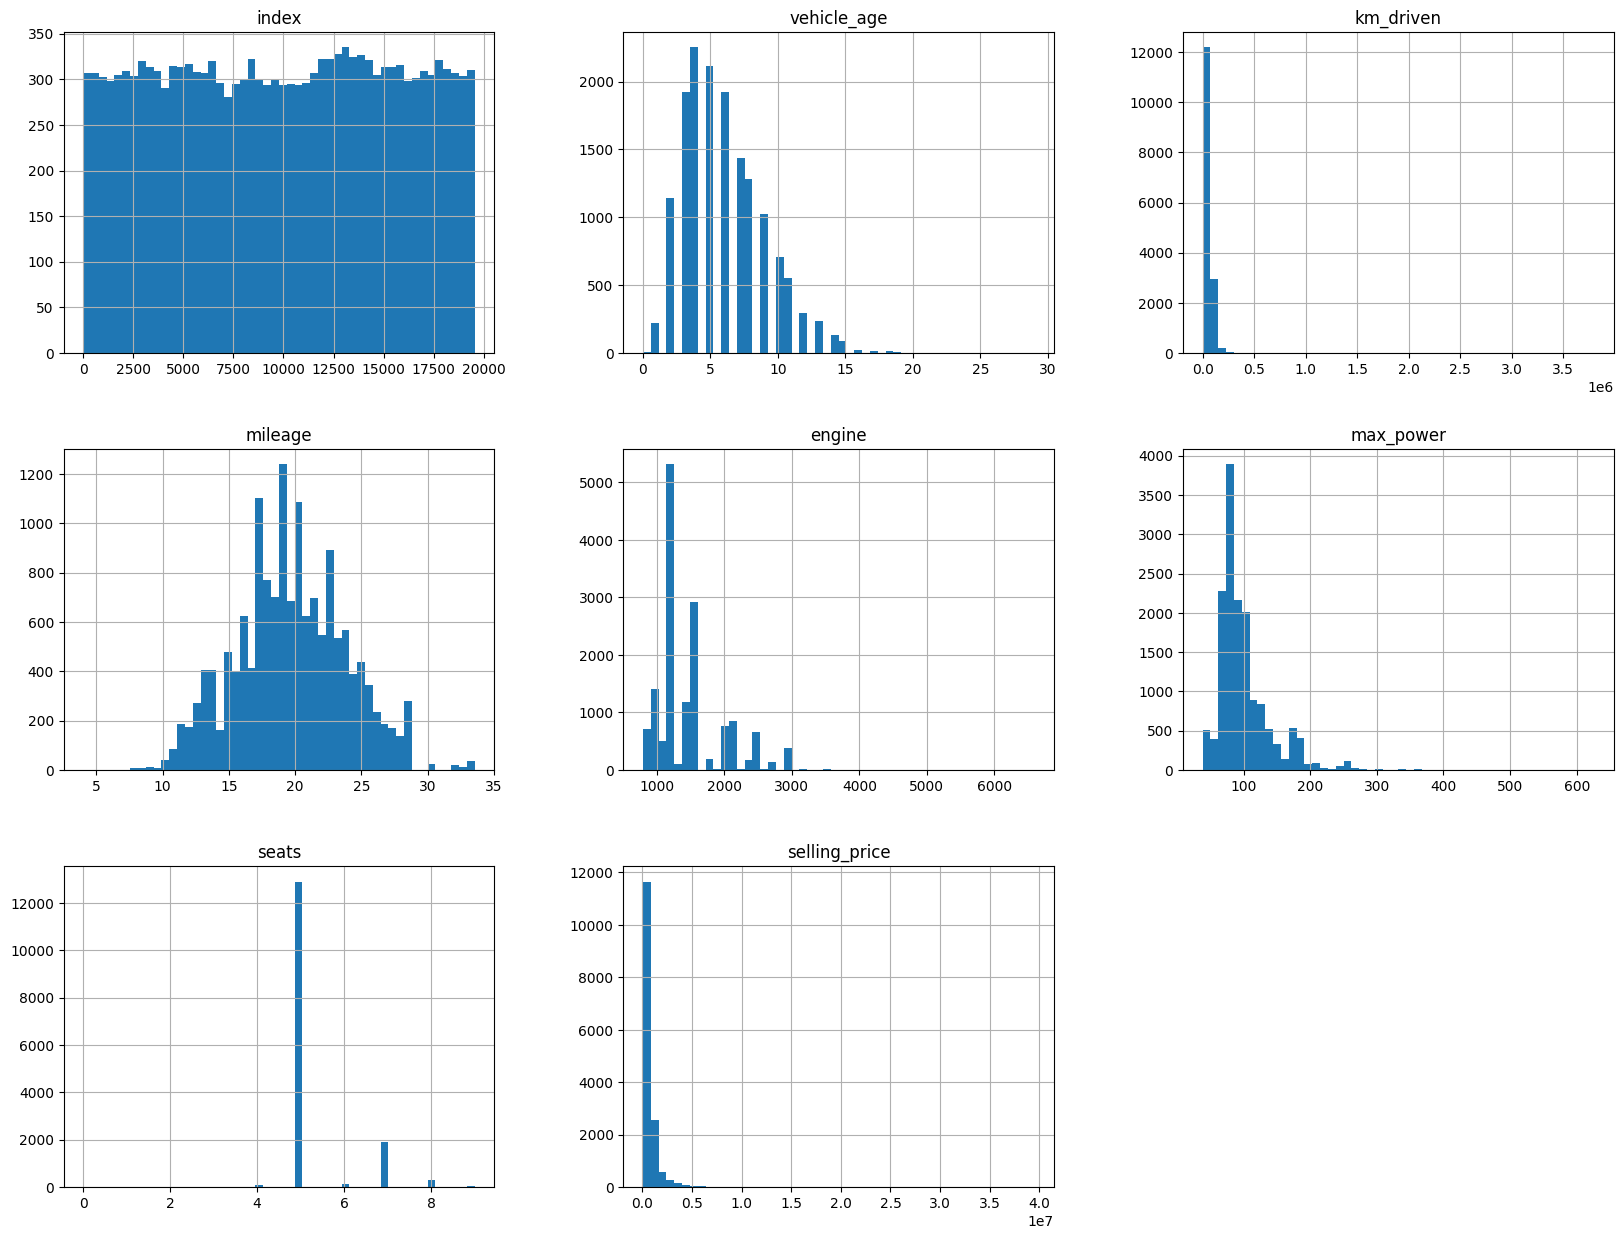

In [10]:
car_data.hist(bins=50 , figsize=(20,15))

#Well before we split the dataset let's see that which attributes have the biggest correlations to the selling price of the car

In [11]:
corr_matrix = car_data.corr(numeric_only=True)

In [12]:
corr_matrix["selling_price"].sort_values(ascending=False)

selling_price    1.000000
max_power        0.750236
engine           0.585844
seats            0.115033
index            0.030523
km_driven       -0.080030
vehicle_age     -0.241851
mileage         -0.305549
Name: selling_price, dtype: float64

-#FROM THIS WE GOT THE BASIC "LINEAR" RELATION BT THE ATTRIBUTES AND NOW WE DO 2D ANALYSIS USING SCATTER METHOD

array([[<Axes: xlabel='selling_price', ylabel='selling_price'>,
        <Axes: xlabel='max_power', ylabel='selling_price'>,
        <Axes: xlabel='engine', ylabel='selling_price'>,
        <Axes: xlabel='seats', ylabel='selling_price'>],
       [<Axes: xlabel='selling_price', ylabel='max_power'>,
        <Axes: xlabel='max_power', ylabel='max_power'>,
        <Axes: xlabel='engine', ylabel='max_power'>,
        <Axes: xlabel='seats', ylabel='max_power'>],
       [<Axes: xlabel='selling_price', ylabel='engine'>,
        <Axes: xlabel='max_power', ylabel='engine'>,
        <Axes: xlabel='engine', ylabel='engine'>,
        <Axes: xlabel='seats', ylabel='engine'>],
       [<Axes: xlabel='selling_price', ylabel='seats'>,
        <Axes: xlabel='max_power', ylabel='seats'>,
        <Axes: xlabel='engine', ylabel='seats'>,
        <Axes: xlabel='seats', ylabel='seats'>]], dtype=object)

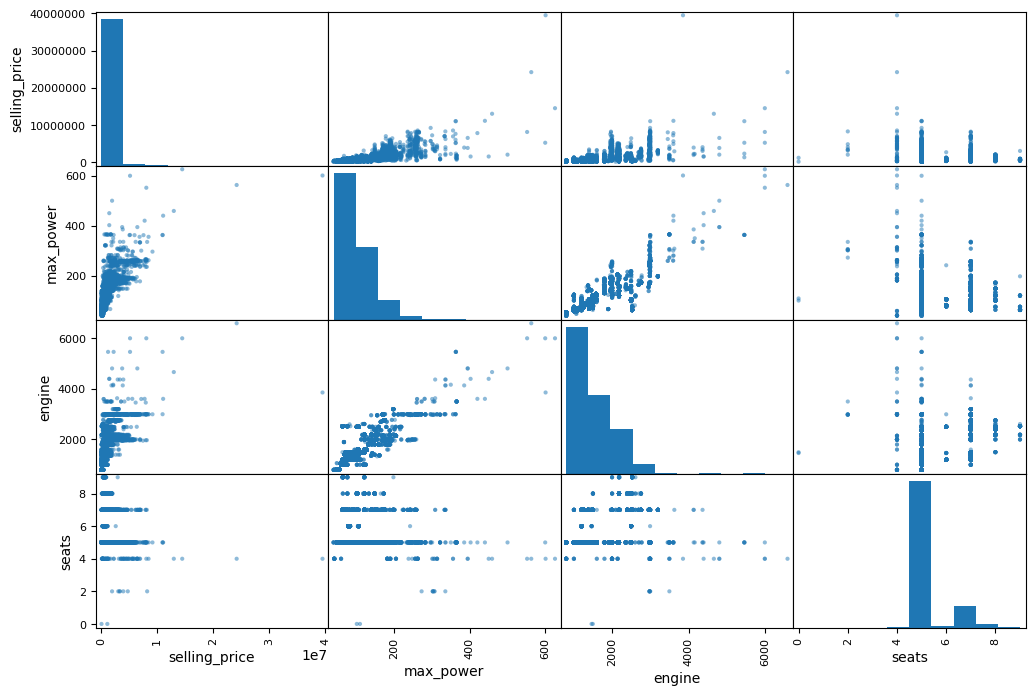

In [13]:
from pandas.plotting import scatter_matrix

attributes = ["selling_price","max_power","engine","seats"]
scatter_matrix(car_data[attributes],figsize=(12,8))

#now lets actually do the stratification based on the "max_power" attribute

Since we are working with a static csv there's not much need of hashing on the on other hand if you are working with  a constantly updating dataset you have to use hashing as that dataset will be a dynamic one 

Creating categories of the selling_price attribute for startified_split 

In [14]:
import numpy as np

In [15]:
car_data["max_power_cat"] = pd.cut(
    car_data["max_power"],
    bins=[0, 50 , 75 , 100 , 125 , 150 ,175, 200, np.inf], 
    labels=[1, 2, 3, 4, 5, 6, 7, 8]
)

max_power_cat
3    5559
2    3987
4    2427
5    1235
6     707
7     554
1     512
8     430
Name: count, dtype: int64

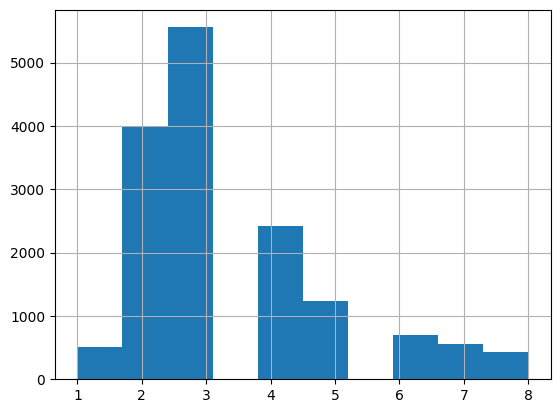

In [16]:
car_data["max_power_cat"].hist()
car_data["max_power_cat"].value_counts()

In [17]:
car_data["max_power_cat"].value_counts(normalize=True)

max_power_cat
3    0.360716
2    0.258711
4    0.157485
5    0.080138
6    0.045876
7    0.035948
1    0.033223
8    0.027902
Name: proportion, dtype: float64

In [18]:
#THERE IS SOMETHING WRONG WITH THE BINS OR SOMETHING LETS CHECK
car_data["max_power"].describe()
car_data["max_power"].unique()[:20]
car_data["max_power"].value_counts().sort_values(ascending=False)[:20]

max_power
74.00     791
88.50     589
81.80     544
98.60     424
67.04     390
67.00     338
140.00    319
81.86     305
82.00     287
47.30     286
81.83     284
67.10     280
67.05     268
88.70     268
78.90     260
126.20    259
121.30    239
73.90     236
120.00    207
85.80     203
Name: count, dtype: int64

In [19]:
car_data["max_power"].head(10)

0     46.30
1     82.00
2     80.00
3     67.10
4     98.59
5     67.10
6     78.90
7     67.04
8    118.35
9     85.00
Name: max_power, dtype: float64

In [20]:
from sklearn.model_selection import StratifiedShuffleSplit

In [21]:
split = StratifiedShuffleSplit(n_splits=1 , test_size= 0.2 , random_state= 46)
for train_index , test_index in split.split(car_data,car_data["max_power_cat"]):
    train_set = car_data.iloc[train_index]
    test_set = car_data.iloc[test_index]

In [22]:
#let's save the data to the processed folder 

In [23]:
train_set.to_csv("../data/processed/train_set.csv",index = False)
test_set.to_csv("../data/processed/test_set.csv",index = False)

##Fearue Engineering

Well we just done with spliting the data now we will have to do PrePrpcessing 

In [24]:
#verify the stratisfication
car_data["max_power"].value_counts(normalize=True)
train_set["max_power"].value_counts(normalize=True)
test_set["max_power"].value_counts(normalize=True)

max_power
74.00     0.048330
88.50     0.042167
81.80     0.034058
67.04     0.025300
67.00     0.024327
            ...   
138.08    0.000324
120.70    0.000324
355.37    0.000324
181.03    0.000324
552.00    0.000324
Name: proportion, Length: 254, dtype: float64

In [25]:
car_data.columns

Index(['index', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price', 'max_power_cat'],
      dtype='str')

In [26]:
train_set["max_power"].value_counts(normalize=True)

max_power
74.00     0.052077
88.50     0.037232
81.80     0.035610
98.60     0.028634
67.04     0.025308
            ...   
147.40    0.000081
122.40    0.000081
260.00    0.000081
394.30    0.000081
179.50    0.000081
Name: proportion, Length: 325, dtype: float64

In [27]:
test_set["max_power"].value_counts(normalize=True)

max_power
74.00     0.048330
88.50     0.042167
81.80     0.034058
67.04     0.025300
67.00     0.024327
            ...   
138.08    0.000324
120.70    0.000324
355.37    0.000324
181.03    0.000324
552.00    0.000324
Name: proportion, Length: 254, dtype: float64

well we have created stratified test and train set , verified the stratification results too 

 # Data Preprocessing

Now that the dataset has been split into training and testing sets, we begin preprocessing the training data. This includes handling missing values, encoding categorical variables, scaling numerical features, and building preprocessing pipelines. Importantly, all preprocessing decisions are learned only from the training data to prevent data leakage.

#CREATING NEW ATTRIBUTES COMBINATION

In [28]:
car_data.head()

,index,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,max_power_cat
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000,1
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000,3
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000,3
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000,2
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000,3


In [29]:
car_data.loc[car_data["vehicle_age"] == 0]

,index,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,max_power_cat
5078,6451,Maruti Ignis,Maruti,Ignis,0,5000,Individual,Petrol,Manual,20.89,1197,81.80,5,550000,3
7789,9985,Mahindra KUV,Mahindra,KUV,0,30000,Individual,Petrol,Manual,18.15,1198,82.00,6,400000,3
10315,13164,BMW 5,BMW,5,0,2000,Dealer,Diesel,Automatic,22.48,1995,187.74,5,4850000,7
11486,14576,BMW 5,BMW,5,0,2000,Dealer,Diesel,Automatic,22.48,1995,187.74,5,4850000,7
12157,15420,Maruti S-Presso,Maruti,S-Presso,0,5000,Individual,Petrol,Manual,21.70,998,67.00,5,500000,2


In [30]:
#lets create a new fearure called "km_per_year" which is the ratio of km_driven and vehicle_age , will help us aseess how worn down the car is based on its age and usage.
car_data["km_per_year"] = car_data["km_driven"]/(car_data["vehicle_age"]+1) #adding 1 to avoid division by zero
car_data["km_per_year"].head()

0    12000.000000
1     3333.333333
2     5000.000000
3     3700.000000
4     4285.714286
Name: km_per_year, dtype: float64

In [31]:
#let's create a new feature called "power per engine" tells us how much the car is performance oriented based on its engine size and power output.
car_data["power_per_engine"] = car_data["max_power"] / car_data["engine"]
car_data["power_per_engine"].head()

0    0.058166
1    0.068505
2    0.066834
3    0.067234
4    0.065814
Name: power_per_engine, dtype: float64

In [32]:
#lets create a new feature called "mileage per engine" tells us how much the car is fuel efficient based on its engine size and mileage output.
car_data["mileage_per_engine"] = car_data["mileage"] / car_data["engine"]
car_data["mileage_per_engine"].head()

0    0.024749
1    0.015789
2    0.014202
3    0.020962
4    0.015200
Name: mileage_per_engine, dtype: float64

#Separate Features and Target

In [33]:
X_train = train_set.drop("selling_price", axis=1)
y_train = train_set["selling_price"]


X_test = test_set.drop("selling_price", axis=1)
y_test = test_set["selling_price"]

In [39]:
X_train.isnull().sum() #tells us how many null values are present in each column of the training set. This is important for data preprocessing, as we may need to handle these missing values before training our model.

index                0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
max_power_cat        0
dtype: int64

In [41]:
X_train.head()

,index,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,max_power_cat
10722,13651,Maruti Baleno,Maruti,Baleno,1,2000,Dealer,Petrol,Manual,21.40,1197,83.10,5,3
9753,12495,Maruti Wagon R,Maruti,Wagon R,14,30000,Individual,Petrol,Manual,18.90,1061,67.00,5,2
13599,17254,Renault KWID,Renault,KWID,5,64000,Individual,Petrol,Manual,25.17,799,53.30,5,2
10996,13978,Honda City,Honda,City,12,58000,Dealer,Petrol,Manual,17.00,1497,118.00,5,4
2438,3110,Hyundai i20,Hyundai,i20,5,43000,Dealer,Diesel,Manual,22.54,1396,88.73,5,3


well we are going to drop index as it's useless , car_name cause it's just brand+model 

In [45]:
X_train.drop(columns=["index","car_name"], inplace=True) #dropping the index column as it is not useful for prediction 


KeyError: "['index', 'car_name'] not found in axis"

well it's ran just i ran it again

In [46]:
y_train.drop(columns = ["index" , "car_name"] , inplace = True)

In [42]:
#well after thoroughly analyzing the data and performing feature engineering, we can now proceed to build our machine learning model for predicting used car prices. The next steps will involve preprocessing the data, selecting appropriate algorithms, training the model, and evaluating its performance.

well let's start encoding the categorical features using one-hot encoding. This will convert categorical variables into a format that can be provided to machine learning algorithms to do a better job in prediction.

#lets first check how many distinct values are present in each categorical column of the training set. This will help us understand the distribution of the data and identify any potential issues with the categorical features.

In [47]:
car_data["model"].nunique()

120

In [50]:
car_data["brand"].nunique()





32

In [51]:
car_data["seller_type"].nunique()


3

In [53]:
car_data["fuel_type"].nunique()

5